In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

df = pd.read_csv('car_data.csv')

df.head()

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


In [56]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   str    
 1   model                2805 non-null   str    
 2   transmission         2805 non-null   str    
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    str    
 5   fuel_type            2805 non-null   str    
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   str    
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   str    
 13  reg_number           2805 non-null   str    
 14  title                2805 non-null   str    
dtypes: float64(4), int64(1), object(1), str(9)
memory

brand                     1
model                     1
transmission              1
make_year                 1
reg_year               2086
fuel_type                 1
engine_capacity(CC)     118
km_driven                 1
ownership                 1
price                     0
overall_cost              1
has_insurance             1
spare_key                 1
reg_number                1
title                     1
dtype: int64

In [57]:
df.drop(['reg_year', 'title', 'reg_number', 'overall_cost'], axis=1, inplace=True)
df.dropna(inplace=True)
print("(Rows, Columns):", df.shape)
df.head()

(Rows, Columns): (2688, 11)


,brand,model,transmission,make_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,has_insurance,spare_key
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,Diesel,2184.0,11003.0,1st owner,1231000,True,No
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,Petrol,1591.0,66936.0,1st owner,786000,True,No
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,Diesel,1956.0,27990.0,1st owner,1489000,True,No
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,Petrol,1498.0,5061.0,1st owner,1227000,True,Yes
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,Diesel,1498.0,23480.0,1st owner,887000,True,No


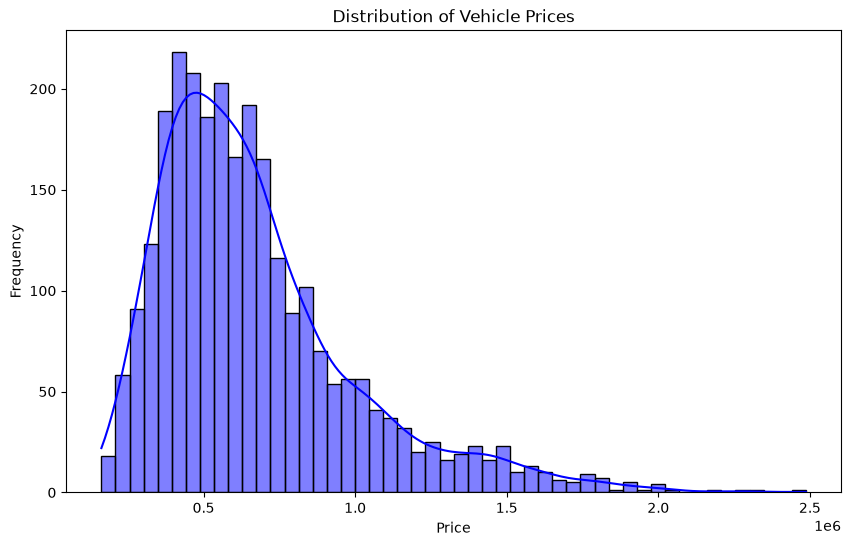

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

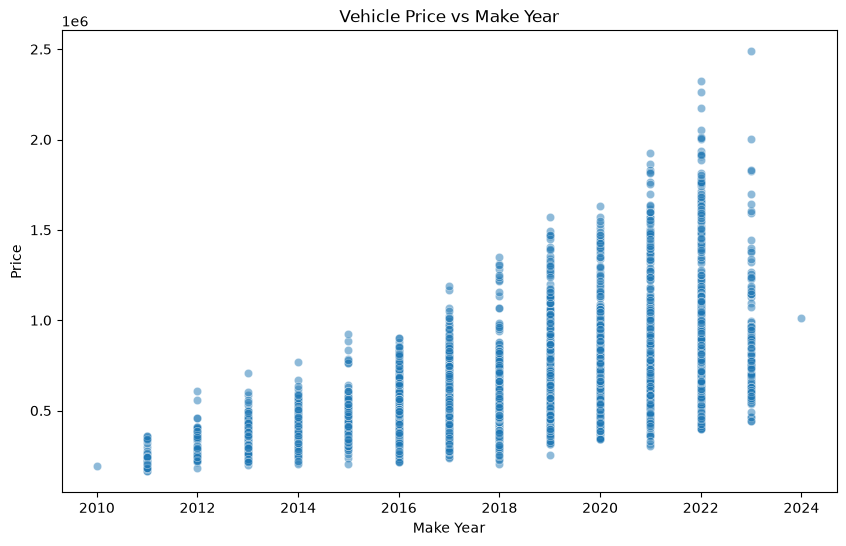

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='make_year', y='price', data=df, alpha=0.5)
plt.title('Vehicle Price vs Make Year')
plt.xlabel('Make Year')
plt.ylabel('Price')
plt.show()

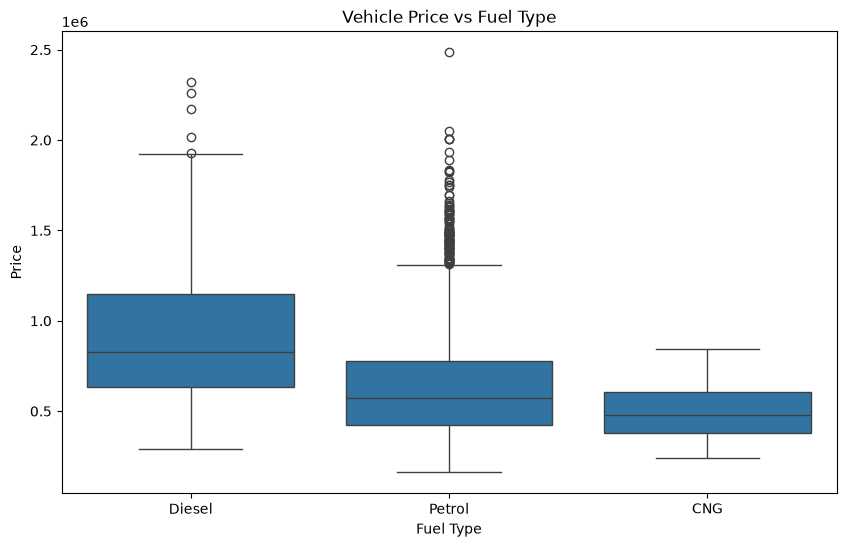

In [62]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel_type', y='price', data=df)
plt.title('Vehicle Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

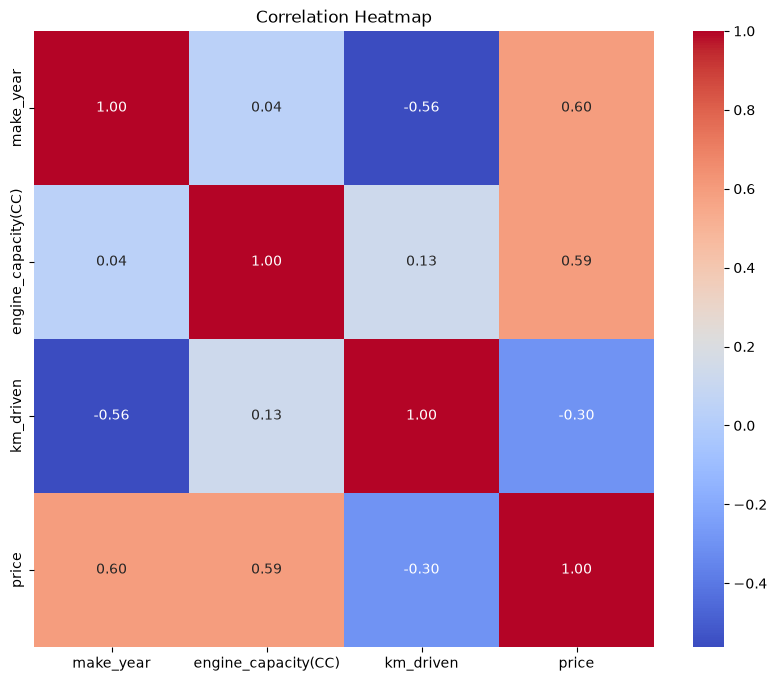

In [63]:
numeric_columns = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [65]:
encoder = LabelEncoder()
categorical_columns = ['brand', 'model', 'transmission', 'fuel_type', 'ownership', 'has_insurance', 'spare_key']

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])


print("Numbrs")
df.head()

Numbrs


,brand,model,transmission,make_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,has_insurance,spare_key
0,7,631,1,2020.0,1,2184.0,11003.0,0,1231000,0,0
1,3,678,1,2018.0,2,1591.0,66936.0,0,786000,0,0
2,12,317,1,2022.0,1,1956.0,27990.0,0,1489000,0,0
3,2,131,0,2023.0,2,1498.0,5061.0,0,1227000,0,1
4,1,208,1,2021.0,1,1498.0,23480.0,0,887000,0,0


In [66]:
X = df.drop('price', axis=1)
y = df['price']

print("X (Features):", X.shape)
print("y (Target):", y.shape)

X (Features): (2688, 10)
y (Target): (2688,)


In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,brand,model,transmission,make_year,fuel_type,engine_capacity(CC),km_driven,ownership,has_insurance,spare_key
0,0.166039,1.139173,0.674784,0.629073,-1.700712,3.635077,-1.441171,-0.584026,0.0,-0.608301
1,-0.985734,1.338079,0.674784,-0.054138,0.392472,1.304629,0.656857,-0.584026,0.0,-0.608301
2,1.605754,-0.189686,0.674784,1.312285,-1.700712,2.739053,-0.803994,-0.584026,0.0,-0.608301
3,-1.273677,-0.976844,-1.481956,1.653891,0.392472,0.939145,-1.664053,-0.584026,0.0,1.643922
4,-1.561620,-0.650978,0.674784,0.970679,-1.700712,0.939145,-0.973163,-0.584026,0.0,-0.608301


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2150, 10)
Testing Data: (538, 10)


In [70]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model Training finish.")

Model Training finish.


In [72]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Absolute Error (MAE): 59838.46
R-squared Score (R2): 0.9375


In [ ]:
joblib.dump(model, 'car_price_predictor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler Saved")

Model and Scaler Saved


In [78]:
import requests

url = 'http://127.0.0.1:5000/predict'

vehicle_data = {
    "brand": 5,                     
    "model": 12,                    
    "transmission": 1,             
    "make_year": 2018,              
    "fuel_type": 1,                 
    "engine_capacity(CC)": 1500.0,  
    "km_driven": 45000.0,           
    "ownership": 0,                
    "has_insurance": 1,             
    "spare_key": 1                 
}

response = requests.post(url, json=vehicle_data)


if response.status_code == 200:
    print("API Successfully")
    print("Estimated Price: Rs.", response.json()['estimated_price'])
else:
    print(" Error:", response.text)

API Successfully
Estimated Price: Rs. 702600.0
